# 311 Complaints Data Pipeline

The script creates a re-runnable data pipe to extract, clean, and transform 311 data, and generate files required by Leaflet.

In [1]:
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
from shapely.geometry import Point 

# os.getcwd()

In [7]:
"""
from google.colab import drive

# Prompt user to mount Google Drive
mount_drive = input("Do you want to mount Google Drive? (yes/no): ").lower()

if mount_drive == 'yes':
    drive.mount('/content/drive')
    content_folder = '/content/drive/MyDrive/nyc310/'
    print(f"Google Drive mounted. content_folder set to: {content_folder}")
else:
    content_folder = '/content/'
    print(f"Google Drive not mounted. content_folder set to: {content_folder}")
"""
content_folder = "./"

## Load and Clean data

In [8]:
df = pd.read_csv(f'{content_folder}nyc_complaints_all.csv')

# drop na
df = df.dropna(subset=['Latitude', 'Longitude','Created Date', 'Complaint Type'])

# create year_month
df['created_date'] = pd.to_datetime(df['Created Date'])
df['year_month'] = df['created_date'].dt.to_period('M').astype(str)

# merge complaint_types
df['Complaint Type'] = df['Complaint Type'].replace({
    # Basket Complaint
    'Litter Basket Complaint': 'Basket',
    'Overflowing Litter Baskets': 'Basket',
    'Recycling Basket Complaint': 'Basket',
    'Litter Basket / Request': 'Basket',
    'Litter Basket Request': 'Basket',
    'Adopt-A-Basket': 'Basket',
    'Overflowing Recycling Baskets': 'Basket',
    # Sweeping Complaint
    'Street Sweeping Complaint': 'Sweeping',
    'Sweeping/Missed-Inadequate': 'Sweeping',
    'Sweeping/Inadequate': 'Sweeping',
    'Sweeping/Missed': 'Sweeping',
    # Missing Collection
    'Missed Collection': 'Collection',
    'Missed Collection (All Materials)': 'Collection',
    'Seasonal Collection' : 'Collection',
    'Request Xmas Tree Collection': 'Collection',
    'Request Large Bulky Item Collection': 'Collection', 
    'Missing Collection': 'Collection',
    'Collection Truck Noise': 'Collection',
    'Change Collection Schedule': 'Collection',
})

# select columns
df = df[['Unique Key', 'created_date', 'year_month', 'Complaint Type', 'Borough','Incident Zip', 'Latitude', 'Longitude']]

/var/folders/vw/ydzq1tx53fb69cs8njql63qm0000gn/T/ipykernel_57022/1639879703.py:1: DtypeWarning: Columns (13,14,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{content_folder}nyc_complaints_all.csv')


In [11]:
print('=========Complaint Types=========', df["Complaint Type"].unique())

=========Complaint Types========= ['Sweeping' 'Collection' 'Basket']


## From `NYC_census_tract.geojson` get `GEOID`

In [9]:
# 1. Load the 'NYC_census_tract.geojson' file into a GeoDataFrame
nyc_census_tract_geo = gpd.read_file(f'../../public/data/311/NYC_census_tract.geojson')

print("GeoDataFrame 'nyc_census_tract_geo' loaded successfully.")

# 2. Display the first few rows of the GeoDataFrame
#print("\nFirst few rows of nyc_census_tract_geo:")
#print(nyc_census_tract_geo.head())

# 3. Print the information about the GeoDataFrame
print("\nDataFrame info for nyc_census_tract_geo:")
nyc_census_tract_geo.info()

# 4. Print the Coordinate Reference System (CRS) of the GeoDataFrame
print(f"\nCRS of nyc_census_tract_geo: {nyc_census_tract_geo.crs}")

GeoDataFrame 'nyc_census_tract_geo' loaded successfully.

DataFrame info for nyc_census_tract_geo:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   OBJECTID       2325 non-null   int32   
 1   CTLabel        2325 non-null   object  
 2   BoroCode       2325 non-null   object  
 3   BoroName       2325 non-null   object  
 4   CT2020         2325 non-null   object  
 5   BoroCT2020     2325 non-null   object  
 6   CDEligibil     2325 non-null   object  
 7   NTAName        2325 non-null   object  
 8   NTA2020        2325 non-null   object  
 9   CDTA2020       2325 non-null   object  
 10  CDTANAME       2325 non-null   object  
 11  GEOID          2325 non-null   object  
 12  PUMA           2325 non-null   object  
 13  Shape__Area    2325 non-null   float64 
 14  Shape__Length  2325 non-null   float64 
 15  geometry       2

The next step is to convert the `df` DataFrame into a GeoDataFrame using the 'Latitude' and 'Longitude' columns. This involves filtering out rows with missing geographical coordinates, creating shapely Point objects, and setting the appropriate CRS (EPSG:4326) to align with the `nyc_census_tract_geo` GeoDataFrame.



In [10]:
from shapely.geometry import Point

# Filter out rows with missing Latitude or Longitude
df_complaints_geo = df.dropna(subset=['Latitude', 'Longitude']).copy()

# Create point geometries
df_complaints_geo['geometry'] = df_complaints_geo.apply(
    lambda row: Point(row['Longitude'], row['Latitude']), axis=1
)

# Convert to GeoDataFrame and set CRS to EPSG:4326
geodata_complaints = gpd.GeoDataFrame(df_complaints_geo, geometry='geometry', crs='EPSG:4326')

print("GeoDataFrame 'geodata_complaints' created successfully from 'df'.")
print("First few rows of geodata_complaints:")
print(geodata_complaints.head())
print(f"\nShape of geodata_complaints: {geodata_complaints.shape}")
print(f"\nCRS of geodata_complaints: {geodata_complaints.crs}")

GeoDataFrame 'geodata_complaints' created successfully from 'df'.
First few rows of geodata_complaints:
     Unique Key        created_date year_month Complaint Type   Borough  \
180    27025605 2013-12-31 12:27:00    2013-12       Sweeping  BROOKLYN   
181    27028413 2013-12-31 11:13:00    2013-12       Sweeping     BRONX   
182    27027316 2013-12-31 10:27:00    2013-12       Sweeping  BROOKLYN   
183    27026170 2013-12-31 10:05:00    2013-12       Sweeping     BRONX   
184    27016863 2013-12-30 14:19:00    2013-12       Sweeping    QUEENS   

     Incident Zip   Latitude  Longitude                    geometry  
180       11214.0  40.589433 -73.990070  POINT (-73.99007 40.58943)  
181       10472.0  40.828884 -73.866614  POINT (-73.86661 40.82888)  
182       11215.0  40.670480 -73.980245  POINT (-73.98025 40.67048)  
183       10472.0  40.835547 -73.877973  POINT (-73.87797 40.83555)  
184       11369.0  40.759713 -73.863871  POINT (-73.86387 40.75971)  

Shape of geodata_complai

The next step is to spatially join the `geodata_complaints` with `nyc_census_tract_geo` to assign a census tract ID to each complaint. Then, the extracted census tract IDs will be merged back into the main `df` DataFrame based on the 'Unique Key' to fulfill the task's requirement.



In [11]:
# Ensure both GeoDataFrames have the same CRS before spatial joining
# geodata_complaints and nyc_census_tract_geo already have EPSG:4326

# Perform spatial join using 'within' predicate
# Use a left join to keep all complaints from geodata_complaints
complaints_with_census_tract = gpd.sjoin(
    geodata_complaints,
    nyc_census_tract_geo[['GEOID', 'geometry']], # Select only necessary columns from census tracts
    how='left',
    predicate='within'
)

print("Spatial join completed successfully.")
print("First few rows of complaints_with_census_tract (joined with census tract data):")
print(complaints_with_census_tract.head())
print(f"\nShape of complaints_with_census_tract: {complaints_with_census_tract.shape}")

# Prepare the census tract ID for merging back to the original df
census_tract_mapping = complaints_with_census_tract[['Unique Key', 'GEOID']].copy()
census_tract_mapping.rename(columns={'GEOID': 'census_tract_id'}, inplace=True)

# Merge the census_tract_id back into the original df DataFrame
df = df.merge(census_tract_mapping, on='Unique Key', how='left')

print("\nCensus tract IDs merged back into the original 'df' DataFrame.")
print("First few rows of 'df' with the new 'census_tract_id' column:")
print(df[['Unique Key', 'Latitude', 'Longitude', 'census_tract_id']].head())
print(f"\nColumns in 'df' after merge: {df.columns.tolist()}")

Spatial join completed successfully.
First few rows of complaints_with_census_tract (joined with census tract data):
     Unique Key        created_date year_month Complaint Type   Borough  \
180    27025605 2013-12-31 12:27:00    2013-12       Sweeping  BROOKLYN   
181    27028413 2013-12-31 11:13:00    2013-12       Sweeping     BRONX   
182    27027316 2013-12-31 10:27:00    2013-12       Sweeping  BROOKLYN   
183    27026170 2013-12-31 10:05:00    2013-12       Sweeping     BRONX   
184    27016863 2013-12-30 14:19:00    2013-12       Sweeping    QUEENS   

     Incident Zip   Latitude  Longitude                    geometry  \
180       11214.0  40.589433 -73.990070  POINT (-73.99007 40.58943)   
181       10472.0  40.828884 -73.866614  POINT (-73.86661 40.82888)   
182       11215.0  40.670480 -73.980245  POINT (-73.98025 40.67048)   
183       10472.0  40.835547 -73.877973  POINT (-73.87797 40.83555)   
184       11369.0  40.759713 -73.863871  POINT (-73.86387 40.75971)   

     

## From `Community_Districts.csv` get `BoroCD`

In [12]:
df_community_districts = pd.read_csv(f'{content_folder}Community_Districts.csv')

In [13]:
from shapely import wkt

# 1. Convert 'the_geom' column to geometry objects
df_community_districts['geometry'] = gpd.GeoSeries.from_wkt(df_community_districts['the_geom'])

# 2. Create a new GeoDataFrame named geodata_community_districts
geodata_community_districts = gpd.GeoDataFrame(df_community_districts, geometry='geometry')

# 3. Set the Coordinate Reference System (CRS) to EPSG:4326
geodata_community_districts.crs = 'EPSG:4326'

print("GeoDataFrame 'geodata_community_districts' created successfully.")
print(f"\nShape of geodata_community_districts: {geodata_community_districts.shape}")
print(f"\nCRS of geodata_community_districts: {geodata_community_districts.crs}")

GeoDataFrame 'geodata_community_districts' created successfully.

Shape of geodata_community_districts: (71, 5)

CRS of geodata_community_districts: EPSG:4326


In [14]:
complaints_with_community_districts = gpd.sjoin(
    geodata_complaints,
    geodata_community_districts[['BoroCd', 'geometry']],
    how='left',
    predicate='within'
)

print("Spatial join completed successfully, assigning 'BoroCd' to complaints.")


Spatial join completed successfully, assigning 'BoroCd' to complaints.


In [15]:
community_district_mapping = complaints_with_community_districts[['Unique Key', 'BoroCd']].copy()

df = df.merge(community_district_mapping, on='Unique Key', how='left')

df.dropna(subset=['BoroCd'], inplace=True)
df['BoroCd'] = df.BoroCd.astype(int)

print("\nBoroCD merged back into the original 'df' DataFrame.")
df.head()


BoroCD merged back into the original 'df' DataFrame.


,Unique Key,created_date,year_month,Complaint Type,Borough,Incident Zip,Latitude,Longitude,census_tract_id,BoroCd
0,27025605,2013-12-31 12:27:00,2013-12,Sweeping,BROOKLYN,11214.0,40.589433,-73.990070,36047031401,313
1,27028413,2013-12-31 11:13:00,2013-12,Sweeping,BRONX,10472.0,40.828884,-73.866614,36005007000,209
2,27027316,2013-12-31 10:27:00,2013-12,Sweeping,BROOKLYN,11215.0,40.670480,-73.980245,36047015500,306
3,27026170,2013-12-31 10:05:00,2013-12,Sweeping,BRONX,10472.0,40.835547,-73.877973,36005006200,209
4,27016863,2013-12-30 14:19:00,2013-12,Sweeping,QUEENS,11369.0,40.759713,-73.863871,36081036500,403


In [16]:
df.to_csv(f'{content_folder}nyc_complaints_cleaned.csv', index=False)

## Aggregate on census_tract_id

In [17]:
# Aggregate on year_month, complaint_type, and census_tract_id
aggregated_df = df.groupby(['year_month', 'Complaint Type', 'census_tract_id']).size().reset_index(name='complaint_count')
aggregated_df.to_csv(content_folder + 'aggregated_complaint_census_tract.csv', index=False)
aggregated_df.to_json(content_folder + 'aggregated_complaint_census_tract.json', orient='records', indent=4)
print("DataFrame saved to 'aggregated_complaint_census_tract.json'")

DataFrame saved to 'aggregated_complaint_census_tract.json'


### Create optimized JSON

In [18]:
sum_df = aggregated_df.groupby(['year_month', 'census_tract_id'])['complaint_count'].sum().reset_index()
sum_df['Complaint Type'] = 'All'
aggregated_df = pd.concat([aggregated_df, sum_df], ignore_index=True)


In [19]:
# Create Nested Dictionary Structure: Complaint Type -> year_month -> census_tract_id -> complaint_count
optimized_data = {}

for index, row in aggregated_df.iterrows():
    complaint_type = row['Complaint Type']
    year_month = row['year_month']
    census_tract_id = row['census_tract_id']
    complaint_count = row['complaint_count']

    if complaint_type not in optimized_data:
        optimized_data[complaint_type] = {}

    if year_month not in optimized_data[complaint_type]:
        optimized_data[complaint_type][year_month] = {}

    optimized_data[complaint_type][year_month][census_tract_id] = complaint_count

print("Optimized nested dictionary created successfully.")


Optimized nested dictionary created successfully.


In [20]:
# save JSON file
import json

output_json_path = '../../public/data/311/optimized_complaint_census_tract.json'

with open(output_json_path, 'w') as f:
    json.dump(optimized_data, f, indent=None) # Set indent to None for compact JSON

print(f"Optimized nested dictionary saved to '{output_json_path}' successfully.")

Optimized nested dictionary saved to '../../public/data/311/optimized_complaint_census_tract.json' successfully.


## Aggregate on community district

In [29]:
# Aggregate on year_month, complaint_type, and BoroCd
aggregated_df = df.groupby(['year_month', 'Complaint Type', 'BoroCd']).size().reset_index(name='complaint_count')
aggregated_df.to_csv(content_folder + 'aggregated_complaint_community_district.csv', index=False)

In [30]:
','.join(sorted(aggregated_df.BoroCd.astype(str).unique()))

'101,102,103,104,105,106,107,108,109,110,111,112,164,201,202,203,204,205,206,207,208,209,210,211,212,226,227,228,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,355,356,401,402,403,404,405,406,407,408,409,410,411,412,413,414,480,481,482,484,501,502,503,595'

## Create file that will not include "Request Large Bulky Item Collection" category


In [2]:
# Paths
csv_path = "nyc_complaints_all.csv"
geojson_path = "../../public/data/311/NYC_census_tract.geojson"
output_json_path = "../../public/data/311/optimized_complaint_census_tract_no_bulky.json"

# Load 311 data
df = pd.read_csv(csv_path)

# Remove bulky item requests
EXCLUDED_TYPES = ["Request Large Bulky Item Collection"]
df = df[~df["Complaint Type"].isin(EXCLUDED_TYPES)]

# Drop missing values
df = df.dropna(subset=["Latitude", "Longitude", "Created Date", "Complaint Type"])

# Parse dates
df["created_date"] = pd.to_datetime(df["Created Date"])
df["year_month"] = df["created_date"].dt.to_period("M").astype(str)

# Simplify complaint types
merge_types = {
    "Litter Basket Complaint": "Basket",
    "Overflowing Litter Baskets": "Basket",
    "Recycling Basket Complaint": "Basket",
    "Litter Basket / Request": "Basket",
    "Litter Basket Request": "Basket",
    "Adopt-A-Basket": "Basket",
    "Overflowing Recycling Baskets": "Basket",

    "Street Sweeping Complaint": "Sweeping",
    "Sweeping/Missed-Inadequate": "Sweeping",
    "Sweeping/Inadequate": "Sweeping",
    "Sweeping/Missed": "Sweeping",

    "Missed Collection": "Collection",
    "Missed Collection (All Materials)": "Collection",
    "Seasonal Collection": "Collection",
    "Request Xmas Tree Collection": "Collection",
    "Missing Collection": "Collection",
    "Collection Truck Noise": "Collection",
    "Change Collection Schedule": "Collection",
}

df["Complaint Type"] = df["Complaint Type"].replace(merge_types)

# Keep needed columns
df = df[[
    "Unique Key", "created_date", "year_month",
    "Complaint Type", "Borough", "Incident Zip",
    "Latitude", "Longitude"
]]

# Load census tract GeoJSON
tracts = gpd.read_file(geojson_path)

# Convert complaints to GeoDataFrame
df["geometry"] = df.apply(lambda r: Point(r["Longitude"], r["Latitude"]), axis=1)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# Spatial Join (find census tract for each complaint)
joined = gpd.sjoin(
    gdf,
    tracts[["GEOID", "geometry"]],
    how="left",
    predicate="within"
)

# Add GEOID back to df
df["census_tract_id"] = joined["GEOID"]

# Aggregate counts
agg = df.groupby(
    ["year_month", "Complaint Type", "census_tract_id"]
).size().reset_index(name="complaint_count")

# Also create "All" combined category
sum_df = agg.groupby(["year_month", "census_tract_id"])["complaint_count"] \
            .sum().reset_index()
sum_df["Complaint Type"] = "All"

agg = pd.concat([agg, sum_df], ignore_index=True)

# Build optimized nested JSON
optimized = {}

for _, row in agg.iterrows():
    ctype = row["Complaint Type"]
    ym = row["year_month"]
    tract = row["census_tract_id"]
    count = row["complaint_count"]

    optimized.setdefault(ctype, {})
    optimized[ctype].setdefault(ym, {})
    optimized[ctype][ym][tract] = count

# Save JSON (compact)
with open(output_json_path, "w") as f:
    json.dump(optimized, f, indent=None)

print("✔ Saved:", output_json_path)

KeyboardInterrupt: 

## Create aggregated data from analysis

In [ ]:
# Paths
csv_path = "nyc_complaints_all.csv"
output_csv = "nyc_complaints_by_borough.csv"

# Load 311 data
df = pd.read_csv(csv_path)

# Remove bulky item requests
EXCLUDED_TYPES = ["Request Large Bulky Item Collection"]
df = df[~df["Complaint Type"].isin(EXCLUDED_TYPES)]

# Drop missing values
df = df.dropna(subset=["Latitude", "Longitude", "Created Date", "Complaint Type"])

# Parse dates
df["created_date"] = pd.to_datetime(df["Created Date"])
df["year_month"] = df["created_date"].dt.to_period("M").astype(str)
df["year"] = df['created_date'].dt.year
df["month"] = df['created_date'].dt.month

# Simplify complaint types
merge_types = {
    "Litter Basket Complaint": "Basket",
    "Overflowing Litter Baskets": "Basket",
    "Recycling Basket Complaint": "Basket",
    "Litter Basket / Request": "Basket",
    "Litter Basket Request": "Basket",
    "Adopt-A-Basket": "Basket",
    "Overflowing Recycling Baskets": "Basket",

    "Street Sweeping Complaint": "Sweeping",
    "Sweeping/Missed-Inadequate": "Sweeping",
    "Sweeping/Inadequate": "Sweeping",
    "Sweeping/Missed": "Sweeping",

    "Missed Collection": "Collection",
    "Missed Collection (All Materials)": "Collection",
    "Seasonal Collection": "Collection",
    "Request Xmas Tree Collection": "Collection",
    "Missing Collection": "Collection",
    "Collection Truck Noise": "Collection",
    "Change Collection Schedule": "Collection",
}

df["Complaint Type"] = df["Complaint Type"].replace(merge_types)

# aggregate
df_aggregate = df.groupby(['year', 'month', 'Complaint Type', 'Borough']).size().reset_index(name='count')

df_aggregate.to_csv(output_csv, index=False)

print("✔ Saved:", output_csv)

C:\Users\42039\AppData\Local\Temp\ipykernel_15096\3236538310.py:6: DtypeWarning: Columns (13,14,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✔ Saved: nyc_complaints_by_borough.csv


In [19]:
import pandas as pd
from scipy import stats

# 1. Load the dataset
df = pd.read_csv('nyc_complaints_by_borough.csv')

# 2. Prepare the data for a Paired T-test
# We are comparing "Collection" complaints between "BRONX" and "MANHATTAN".
# The "pairing" key is the time period (Year and Month).

complaint_type = 'Collection'
borough1 = 'BRONX'
borough2 = 'MANHATTAN'

# Filter for the specific complaint type and boroughs
b1_data = df[(df['Complaint Type'] == complaint_type) & (df['Borough'] == borough1)].copy()
b2_data = df[(df['Complaint Type'] == complaint_type) & (df['Borough'] == borough2)].copy()

# Rename the count columns so we can distinguish them after merging
b1_data = b1_data.rename(columns={'count': f'count_{borough1}'})
b2_data = b2_data.rename(columns={'count': f'count_{borough2}'})

# Merge on 'year' and 'month' to ensure we align the data points correctly.
# This creates the "pairs" for the test.
merged_df = pd.merge(b1_data[['year', 'month', f'count_{borough1}']], 
                     b2_data[['year', 'month', f'count_{borough2}']], 
                     on=['year', 'month'], 
                     how='inner')

# 3. Perform the Paired T-Test
# Function: scipy.stats.ttest_rel
# This tests the null hypothesis that the mean difference between the paired observations is zero.
t_stat, p_value = stats.ttest_rel(merged_df[f'count_{borough1}'], merged_df[f'count_{borough2}'])

# 4. Display Results
print(f"--- Paired T-test Results: {borough1} vs {borough2} ({complaint_type}) ---")
print(f"Number of paired months: {len(merged_df)}")
print(f"Mean {borough1}: {merged_df[f'count_{borough1}'].mean():.2f}")
print(f"Mean {borough2}: {merged_df[f'count_{borough2}'].mean():.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nCONCLUSION: The difference IS statistically significant.")
    print(f"Manhattan consistently has higher collection complaints than The Bronx when controlling for the specific month.")
else:
    print("\nCONCLUSION: The difference is NOT statistically significant.")

--- Paired T-test Results: BRONX vs MANHATTAN (Collection) ---
Number of paired months: 191
Mean BRONX: 222.75
Mean MANHATTAN: 246.64

T-statistic: -5.3733
P-value: 0.0000002247

CONCLUSION: The difference IS statistically significant.
Manhattan consistently has higher collection complaints than The Bronx when controlling for the specific month.


In [20]:
import pandas as pd
from scipy import stats
import itertools

# Load data
df = pd.read_csv('nyc_complaints_by_borough.csv')

# Get lists
complaint_types = df['Complaint Type'].unique()
boroughs = [b for b in df['Borough'].unique() if b != 'Unspecified']

results = []

for c_type in complaint_types:
    # Filter by type
    type_data = df[df['Complaint Type'] == c_type]
    
    # Iterate through all unique pairs of boroughs
    for b1, b2 in itertools.combinations(boroughs, 2):
        # Get data for each borough
        data1 = type_data[type_data['Borough'] == b1]
        data2 = type_data[type_data['Borough'] == b2]
        
        # Merge on year/month to ensure pairs
        merged = pd.merge(data1[['year', 'month', 'count']], 
                          data2[['year', 'month', 'count']], 
                          on=['year', 'month'], 
                          suffixes=('_1', '_2'))
        
        if len(merged) > 20: # Ensure enough samples
            series1 = merged['count_1']
            series2 = merged['count_2']
            
            # Means
            mean1 = series1.mean()
            mean2 = series2.mean()
            
            # 1. Independent T-Test (The "Naive" test)
            indep_t, indep_p = stats.ttest_ind(series1, series2, equal_var=False)
            
            # 2. Paired T-Test (The "True" test)
            rel_t, rel_p = stats.ttest_rel(series1, series2)
            
            # Calc percent diff
            avg_mean = (mean1 + mean2) / 2
            if avg_mean > 0:
                diff_pct = abs(mean1 - mean2) / avg_mean
            else:
                diff_pct = 0
            
            results.append({
                'Type': c_type,
                'B1': b1,
                'B2': b2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Diff_Pct': diff_pct,
                'Indep_P': indep_p,
                'Paired_P': rel_p
            })

results_df = pd.DataFrame(results)

# Filter for the "Illusion" pattern:
# Independent P > 0.05 (Looks insignificant)
# Paired P < 0.05 (Actually significant)
candidates = results_df[(results_df['Indep_P'] > 0.05) & (results_df['Paired_P'] < 0.05)]

# Sort by p-value of paired test (most significant "truth") and Diff Pct
candidates = candidates.sort_values(by=['Paired_P'])

print(candidates)

          Type        B1         B2        Mean1       Mean2  Diff_Pct  \
11  Collection     BRONX  MANHATTAN   222.753927  246.638743  0.101769   
15  Collection  BROOKLYN     QUEENS  1028.026178  941.586387  0.087773   
21    Sweeping     BRONX  MANHATTAN    35.262032   32.529412  0.080618   

     Indep_P      Paired_P  
11  0.081070  2.246616e-07  
15  0.186190  1.265350e-03  
21  0.484279  3.663676e-02  


In [22]:
import pandas as pd
from scipy import stats
import itertools

# Load data
df = pd.read_csv('nyc_complaints_by_borough.csv')

# Get lists
complaint_types = df['Complaint Type'].unique()
boroughs = [b for b in df['Borough'].unique() if b != 'Unspecified']

results = []

for c_type in complaint_types:
    # Filter by type
    type_data = df[df['Complaint Type'] == c_type]
    
    # Iterate through all unique pairs of boroughs
    for b1, b2 in itertools.combinations(boroughs, 2):
        # Get data for each borough
        data1 = type_data[type_data['Borough'] == b1]
        data2 = type_data[type_data['Borough'] == b2]
        
        # Merge on year/month to ensure pairs
        merged = pd.merge(data1[['year', 'month', 'count']], 
                          data2[['year', 'month', 'count']], 
                          on=['year', 'month'], 
                          suffixes=('_1', '_2'))
        
        if len(merged) > 20: # Ensure enough samples
            series1 = merged['count_1']
            series2 = merged['count_2']
            
            # Means
            mean1 = series1.mean()
            mean2 = series2.mean()
            
            # Paired T-Test
            rel_t, rel_p = stats.ttest_rel(series1, series2)
            
            # Calc percent diff
            avg_mean = (mean1 + mean2) / 2
            if avg_mean > 0:
                diff_pct = abs(mean1 - mean2) / avg_mean
            else:
                diff_pct = 0
            
            results.append({
                'Type': c_type,
                'B1': b1,
                'B2': b2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Diff_Pct': diff_pct,
                'Paired_P': rel_p
            })

results_df = pd.DataFrame(results)

# Filter for the "False Alarm" pattern:
# Diff_Pct is noticeable (> 5% or 10%)
# Paired_P > 0.05 (Not significant)
candidates = results_df[(results_df['Paired_P'] > 0.05) & (results_df['Diff_Pct'] > 0.05)].sort_values(by='Diff_Pct', ascending=False)

print("Candidates where averages look different but Paired T-test says 'No':")
print(candidates.head(10))

Candidates where averages look different but Paired T-test says 'No':
Empty DataFrame
Columns: [Type, B1, B2, Mean1, Mean2, Diff_Pct, Paired_P]
Index: []


Mean BRONX: 101.94285714285714
Mean QUEENS: 94.57142857142857


C:\Users\42039\AppData\Local\Temp\ipykernel_15096\1295430505.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[b1, b2], y=[mean1, mean2], ax=axes[0], palette=['#1f77b4', '#ff7f0e'])


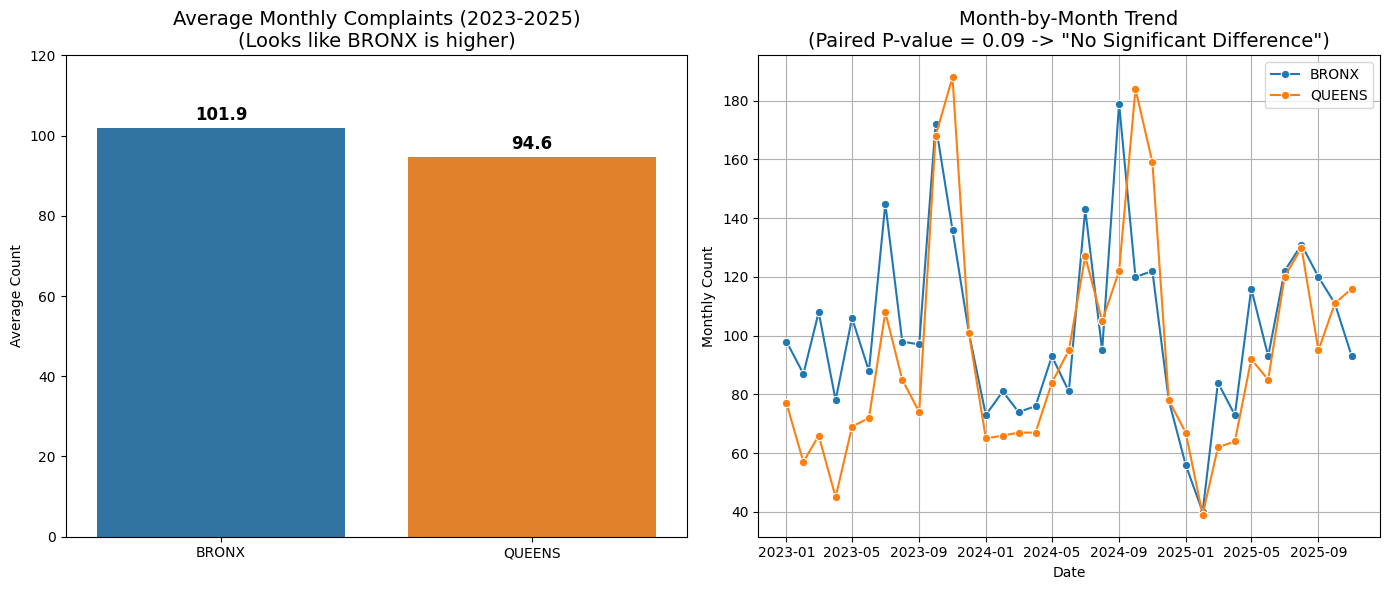

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data
df_recent = df[df['year'] >= 2023]
comp_type = 'Sweeping'
b1 = 'BRONX'
b2 = 'QUEENS'

data1 = df_recent[(df_recent['Complaint Type'] == comp_type) & (df_recent['Borough'] == b1)][['year', 'month', 'count']]
data2 = df_recent[(df_recent['Complaint Type'] == comp_type) & (df_recent['Borough'] == b2)][['year', 'month', 'count']]
merged = pd.merge(data1, data2, on=['year', 'month'], suffixes=(f'_{b1}', f'_{b2}'))

# Stats
mean1 = merged[f'count_{b1}'].mean()
mean2 = merged[f'count_{b2}'].mean()

print(f"Mean {b1}: {mean1}")
print(f"Mean {b2}: {mean2}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. The "Deceptive" Average (Bar Chart)
sns.barplot(x=[b1, b2], y=[mean1, mean2], ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title(f'Average Monthly Complaints (2023-2025)\n(Looks like {b1} is higher)', fontsize=14)
axes[0].set_ylabel('Average Count')
axes[0].set_ylim(0, 120)
# Add labels
for i, v in enumerate([mean1, mean2]):
    axes[0].text(i, v + 2, f"{v:.1f}", ha='center', fontsize=12, fontweight='bold')

# 2. The "True" Paired View (Line Plot of Differences)
# Showing the timeline of counts to show the "flip-flopping"
merged['Date'] = pd.to_datetime(merged[['year', 'month']].assign(DAY=1))
sns.lineplot(x='Date', y=f'count_{b1}', data=merged, ax=axes[1], label=b1, marker='o')
sns.lineplot(x='Date', y=f'count_{b2}', data=merged, ax=axes[1], label=b2, marker='o')
axes[1].set_title(f'Month-by-Month Trend\n(Paired P-value = 0.09 -> "No Significant Difference")', fontsize=14)
axes[1].set_ylabel('Monthly Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('false_positive_trend.png')

In [24]:
# Filter for recent years to reduce N and find a non-significant example
df_recent = df[df['year'] >= 2023]

results_recent = []

for c_type in complaint_types:
    type_data = df_recent[df_recent['Complaint Type'] == c_type]
    
    for b1, b2 in itertools.combinations(boroughs, 2):
        data1 = type_data[type_data['Borough'] == b1]
        data2 = type_data[type_data['Borough'] == b2]
        
        merged = pd.merge(data1[['year', 'month', 'count']], 
                          data2[['year', 'month', 'count']], 
                          on=['year', 'month'], 
                          suffixes=('_1', '_2'))
        
        if len(merged) > 10:
            s1 = merged['count_1']
            s2 = merged['count_2']
            
            mean1 = s1.mean()
            mean2 = s2.mean()
            
            rel_t, rel_p = stats.ttest_rel(s1, s2)
            
            avg_mean = (mean1 + mean2) / 2
            if avg_mean > 0:
                diff_pct = abs(mean1 - mean2) / avg_mean
            else:
                diff_pct = 0
            
            results_recent.append({
                'Type': c_type,
                'B1': b1,
                'B2': b2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Diff_Pct': diff_pct,
                'Paired_P': rel_p
            })

df_recent_res = pd.DataFrame(results_recent)

# Filter for visible difference (>5%) but NOT significant (P > 0.05)
candidates_recent = df_recent_res[(df_recent_res['Paired_P'] > 0.05) & (df_recent_res['Diff_Pct'] > 0.05)].sort_values(by='Diff_Pct', ascending=False)

print("Candidates in Recent Data (2023-2025):")
print(candidates_recent.head(10))

Candidates in Recent Data (2023-2025):
        Type     B1      B2       Mean1      Mean2  Diff_Pct  Paired_P
22  Sweeping  BRONX  QUEENS  101.942857  94.571429  0.075022  0.087993


In [25]:
import pandas as pd
from scipy import stats
import itertools

# Load data
df = pd.read_csv('nyc_complaints_by_borough.csv')

# 1. Aggregate ALL complaint types
# Group by Year, Month, Borough and sum the counts
df_agg = df.groupby(['year', 'month', 'Borough'])['count'].sum().reset_index()

# Get boroughs list
boroughs = [b for b in df_agg['Borough'].unique() if b != 'Unspecified']

def run_analysis(data_source, label):
    results = []
    for b1, b2 in itertools.combinations(boroughs, 2):
        data1 = data_source[data_source['Borough'] == b1]
        data2 = data_source[data_source['Borough'] == b2]
        
        # Merge to ensure pairs
        merged = pd.merge(data1[['year', 'month', 'count']], 
                          data2[['year', 'month', 'count']], 
                          on=['year', 'month'], 
                          suffixes=('_1', '_2'))
        
        if len(merged) > 10:
            s1 = merged['count_1']
            s2 = merged['count_2']
            
            mean1 = s1.mean()
            mean2 = s2.mean()
            
            # Independent T-test
            indep_t, indep_p = stats.ttest_ind(s1, s2, equal_var=False)
            
            # Paired T-test
            rel_t, rel_p = stats.ttest_rel(s1, s2)
            
            # Diff calculation
            avg_mean = (mean1 + mean2) / 2
            diff_pct = abs(mean1 - mean2) / avg_mean if avg_mean > 0 else 0
            
            results.append({
                'Label': label,
                'Pair': f"{b1} vs {b2}",
                'B1': b1, 'B2': b2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Diff_Pct': diff_pct,
                'Indep_P': indep_p,
                'Paired_P': rel_p,
                'N': len(merged)
            })
    return pd.DataFrame(results)

# Run on Full Data (2010-2025)
df_res_full = run_analysis(df_agg, "Full (2010-2025)")

# Run on Recent Data (2023-2025)
df_recent = df_agg[df_agg['year'] >= 2023]
df_res_recent = run_analysis(df_recent, "Recent (2023-2025)")

# Combine
all_results = pd.concat([df_res_full, df_res_recent])

# Search for "False Alarms" (Avg looks diff, Paired says NO)
# Criteria: Diff > 5% but Paired P > 0.05
candidates_false_alarm = all_results[(all_results['Diff_Pct'] > 0.05) & (all_results['Paired_P'] > 0.05)].sort_values(by='Diff_Pct', ascending=False)

print("Candidates: Average Differs, but Paired Test says NOT Significant:")
print(candidates_false_alarm[['Label', 'Pair', 'Mean1', 'Mean2', 'Diff_Pct', 'Paired_P']])

# Search for "Hidden Differences" (Avg looks same, Paired says YES)
# Criteria: Indep P > 0.05, Paired P < 0.05
candidates_hidden = all_results[(all_results['Indep_P'] > 0.05) & (all_results['Paired_P'] < 0.05)].sort_values(by='Paired_P')

print("\nCandidates: Average Looks Same, but Paired Test says SIGNIFICANT:")
print(candidates_hidden[['Label', 'Pair', 'Mean1', 'Mean2', 'Indep_P', 'Paired_P']])

Candidates: Average Differs, but Paired Test says NOT Significant:
                Label                    Pair       Mean1       Mean2  \
3  Recent (2023-2025)  BRONX vs STATEN ISLAND  467.314286  494.857143   

   Diff_Pct  Paired_P  
3  0.057251  0.158901  

Candidates: Average Looks Same, but Paired Test says SIGNIFICANT:
Empty DataFrame
Columns: [Label, Pair, Mean1, Mean2, Indep_P, Paired_P]
Index: []


C:\Users\42039\AppData\Local\Temp\ipykernel_15096\2871268140.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[b1, b2], y=[mean1, mean2], ax=axes[0], palette=['#1f77b4', '#2ca02c'])


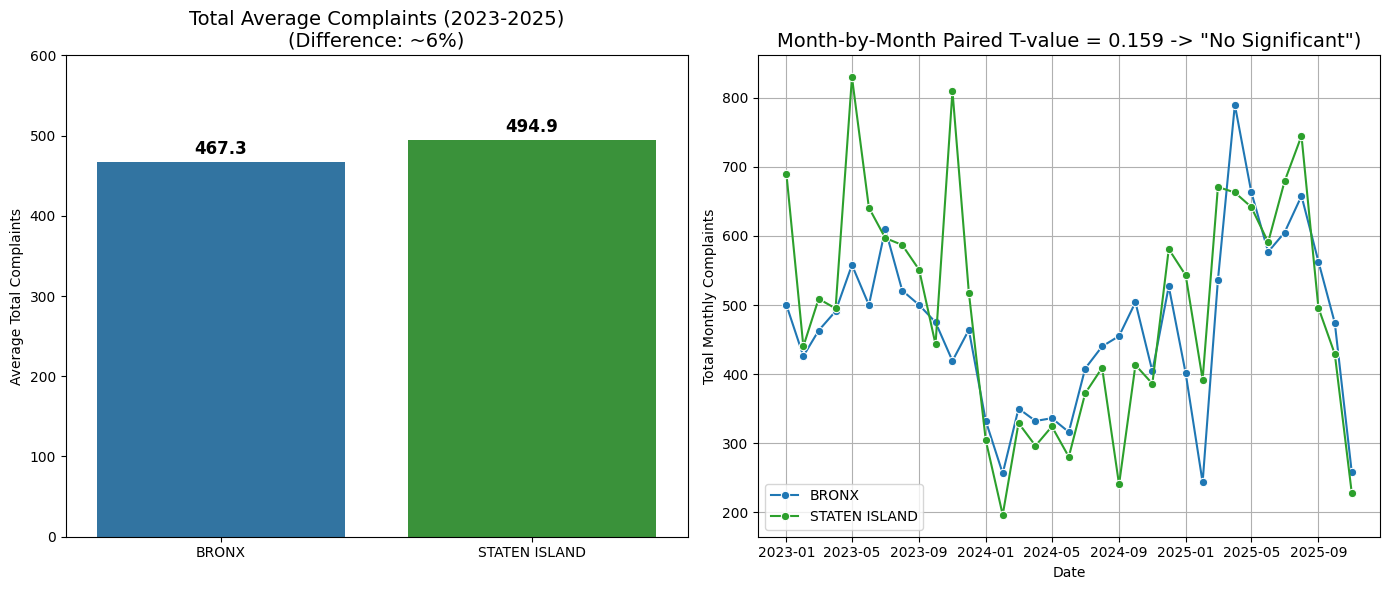

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data
# We need to recreate the aggregated recent dataframe for plotting
df_agg = df.groupby(['year', 'month', 'Borough'])['count'].sum().reset_index()
df_recent = df_agg[df_agg['year'] >= 2023]

b1 = 'BRONX'
b2 = 'STATEN ISLAND'

data1 = df_recent[df_recent['Borough'] == b1]
data2 = df_recent[df_recent['Borough'] == b2]
merged = pd.merge(data1[['year', 'month', 'count']], 
                  data2[['year', 'month', 'count']], 
                  on=['year', 'month'], 
                  suffixes=(f'_{b1}', f'_{b2}'))

# Stats
mean1 = merged[f'count_{b1}'].mean()
mean2 = merged[f'count_{b2}'].mean()
p_val = stats.ttest_rel(merged[f'count_{b1}'], merged[f'count_{b2}'])[1]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar Chart (The "Illusion")
sns.barplot(x=[b1, b2], y=[mean1, mean2], ax=axes[0], palette=['#1f77b4', '#2ca02c'])
axes[0].set_title(f'Total Average Complaints (2023-2025)\n(Difference: ~6%)', fontsize=14)
axes[0].set_ylabel('Average Total Complaints')
axes[0].set_ylim(0, 600)
for i, v in enumerate([mean1, mean2]):
    axes[0].text(i, v + 10, f"{v:.1f}", ha='center', fontsize=12, fontweight='bold')

# 2. Line Chart (The "Reality")
merged['Date'] = pd.to_datetime(merged[['year', 'month']].assign(DAY=1))
sns.lineplot(x='Date', y=f'count_{b1}', data=merged, ax=axes[1], label=b1, marker='o', color='#1f77b4')
sns.lineplot(x='Date', y=f'count_{b2}', data=merged, ax=axes[1], label=b2, marker='o', color='#2ca02c')

axes[1].set_title(f'Month-by-Month Paired T-value = {p_val:.3f} -> "No Significant")', fontsize=14)
axes[1].set_ylabel('Total Monthly Complaints')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('total_complaints_illusion.png')

In [30]:
merged.shape

(35, 5)